#Deep Learning Module End Assignment

###1. Loading and Preprocessing

The Diabetes dataset from sklearn is a regression dataset with 442 samples and 10 features.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# Load data
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [3]:
# Check for missing values
print(f"Missing values: {np.isnan(X).sum()}")

Missing values: 0


In [4]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

###2. Exploratory Data Analysis

###Distribution:
Visualize how the target variable (diabetes progression) is spread.
###Relationships:
Use a heatmap to show how features relate to the target.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#Convert to DataFrame for easier visualization
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

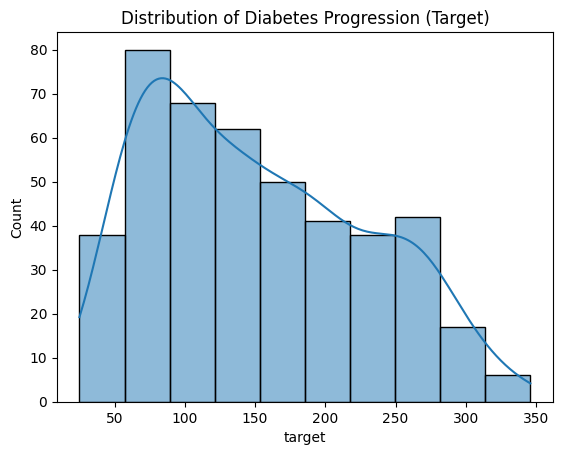

In [8]:
#Visualize distribution of the target variable
sns.histplot(df['target'], kde=True)
plt.title('Distribution of Diabetes Progression (Target)')
plt.show()

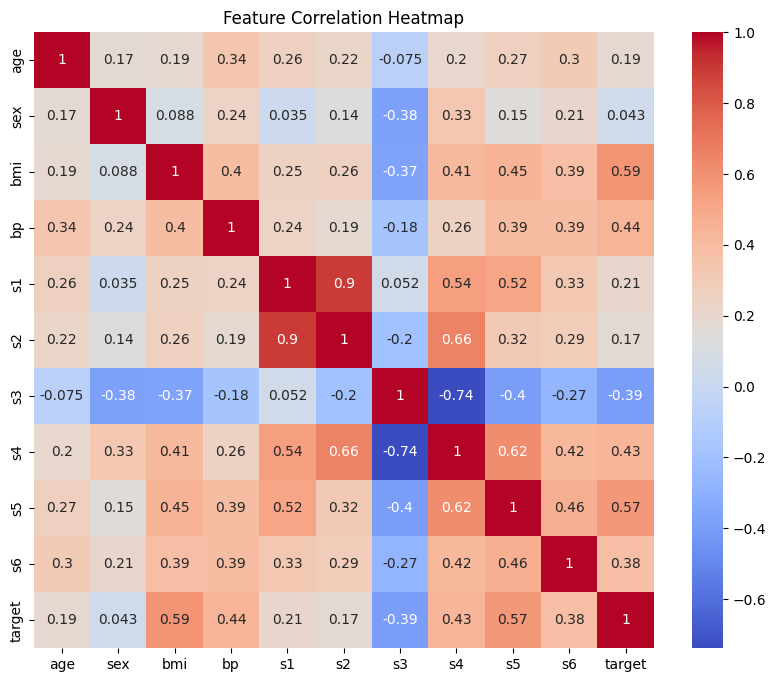

In [9]:
#Correlation Heatmap to see relationships
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

###3. Building the ANN Model

###Architecture:
Design a Sequential model with at least one hidden layer.
###Activation:
Use relu for hidden layers and a linear output for regression.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [11]:
#Design the ANN architecture
model = Sequential([
    # Step 1: Define the input shape explicitly
    Input(shape=(X_train.shape[1],)),

    # Step 2: Hidden layers
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    # Step 3: Output layer for regression
    Dense(1)
])

# Compile as usual
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

###4. Training the ANN Model

Now we split the data and feed it into the architecture defined above. We will use a validation split to monitor if the model is overfitting during training

In [12]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets [cite: 19]
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [13]:
#Train the model [cite: 20]
#epochs=100 means the model will see the entire dataset 100 times
#validation_split=0.2 holds back 20% of training data to check performance during training
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 31079.6836 - mae: 157.2390 - val_loss: 21725.9902 - val_mae: 131.2985
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29858.1055 - mae: 153.4627 - val_loss: 20387.5898 - val_mae: 126.4013
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27208.7031 - mae: 145.3824 - val_loss: 17866.0254 - val_mae: 116.7936
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22585.4570 - mae: 129.7655 - val_loss: 13849.1299 - val_mae: 100.2705
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15961.6367 - mae: 105.2887 - val_loss: 9218.4180 - val_mae: 76.6523
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9735.3047 - mae: 77.9523 - val_loss: 5700.6631 - val_mae: 55.8835
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6331.9009 - mae: 61.8010 - val_loss: 4284.5630 - val_mae: 48.1170
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5259.0884 - mae: 56.8028 - val_loss: 3783.1865 -

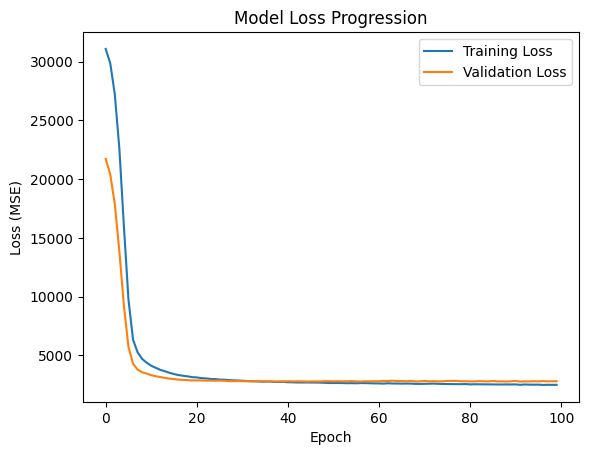

In [14]:
# Plotting the training history to visualize loss reduction
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

###5. Evaluating the Model

Evaluate using metrics like Mean Squared Error (MSE) and the $R^2$ Score.

###A. Performance Metrics Report Table

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

# Generate predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a Report Table
metrics_data = {
    'Metric': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)', 'R2 Score'],
    'Value': [f"{mse:.2f}", f"{rmse:.2f}", f"{mae:.2f}", f"{r2:.2f}"]
}

report_df = pd.DataFrame(metrics_data)
print("Performance Metrics Report:")
display(report_df)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Performance Metrics Report:


,Metric,Value
0,Mean Squared Error (MSE),2745.46
1,Root Mean Squared Error (RMSE),52.40
2,Mean Absolute Error (MAE),41.49
3,R2 Score,0.48


###B. Visualization: Actual vs. Predicted Values

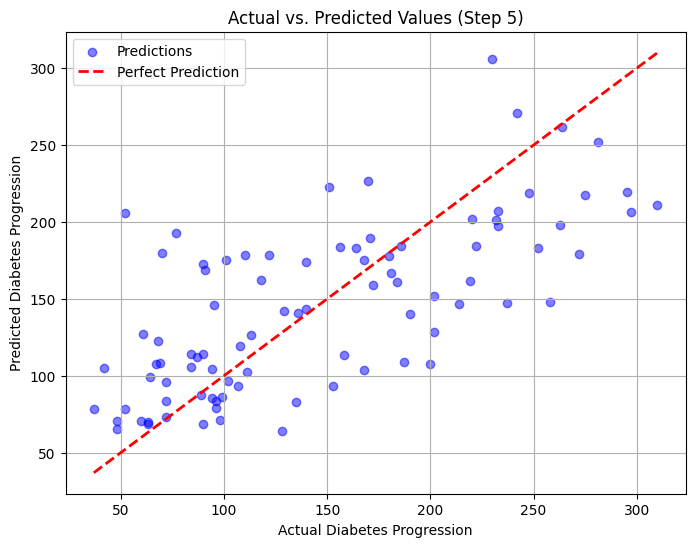

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Diabetes Progression')
plt.ylabel('Predicted Diabetes Progression')
plt.title('Actual vs. Predicted Values (Step 5)')
plt.legend()
plt.grid(True)
plt.show()

###6. Improving the Model

In [17]:
from tensorflow.keras.layers import Dropout, Input

# Improved Architecture
improved_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),      # Increased neurons
    Dropout(0.2),                       # Prevents overfitting
    Dense(64, activation='relu'),       # Added an extra layer
    Dense(32, activation='relu'),
    Dense(1)
])

# Using a custom learning rate for the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

improved_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Increase training epochs to give the deeper model time to learn
history_improved = improved_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Evaluate the improved model
y_pred_improved = improved_model.predict(X_test)
mse_improved = mean_squared_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print(f"Improved MSE: {mse_improved:.2f}")
print(f"Improved R2 Score: {r2_improved:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Improved MSE: 2682.51
Improved R2 Score: 0.49


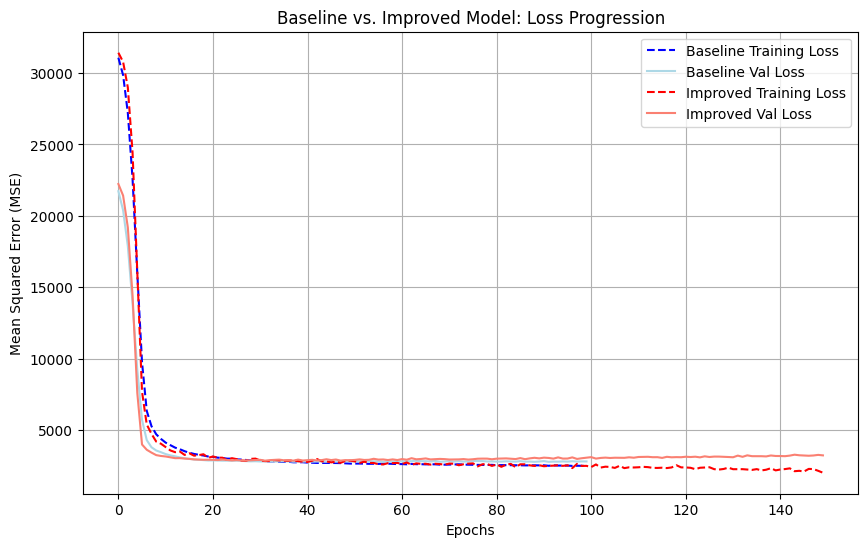

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Baseline Training Loss', color='blue', linestyle='--')
plt.plot(history.history['val_loss'], label='Baseline Val Loss', color='lightblue')

plt.plot(history_improved.history['loss'], label='Improved Training Loss', color='red', linestyle='--')
plt.plot(history_improved.history['val_loss'], label='Improved Val Loss', color='salmon')

plt.title('Baseline vs. Improved Model: Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')

plt.legend()
plt.grid(True)
plt.show()

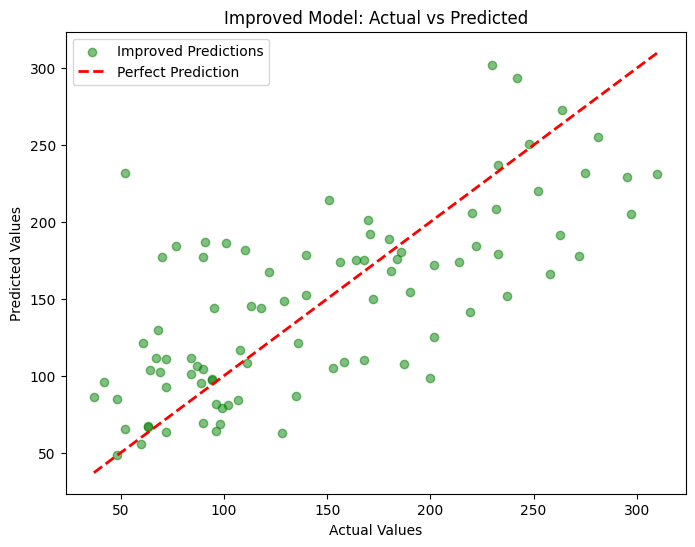

In [19]:
#Optional: Actual vs Predicted for the Improved Model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_improved, alpha=0.5, color='green', label='Improved Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Improved Model: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()